# Nocarz — Eksploracyjna analiza danych (EDA)

**Zadanie biznesowe:** *"W którym miejscu powinniśmy poszukać nowego lokalu, aby był jak najbardziej opłacalny?"*

Modelujemy **roczny przychód lokalu** (`annual_revenue`) na podstawie cech znanych **przed** wystawieniem oferty (lokalizacja, typ, otoczenie rynkowe). Ten notatnik bada dane wejściowe i uzasadnia decyzje modelowe.

Dane: Paryż, ~91 tys. lokali. Cel wyznaczony z `calendar.csv` (przychód = suma cen za noce zarezerwowane, `available == 'f'`, w oknie ~365 dni).

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd()
ROOT = next((q for q in [_p, *_p.parents] if (q / 'src' / 'nocarz').exists()), _p)
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from nocarz.features import PROCESSED_DIR, REPORTS_DIR, TARGET
FIG = REPORTS_DIR / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(PROCESSED_DIR / 'model_table.csv')
print('Wiersze:', len(df), '| Kolumny:', list(df.columns))
df.head()

Wiersze: 91031 | Kolumny: ['id', 'latitude', 'longitude', 'accommodates', 'amenities_count', 'comp_count_250m', 'comp_count_500m', 'comp_count_1000m', 'district_median_price', 'district_mean_review_location', 'neighbourhood_cleansed', 'property_type', 'room_type', 'annual_revenue', 'occupancy']


,id,latitude,longitude,accommodates,amenities_count,comp_count_250m,comp_count_500m,comp_count_1000m,district_median_price,district_mean_review_location,neighbourhood_cleansed,property_type,room_type,annual_revenue,occupancy
0,3109,48.83191,2.31870,2,15,306.0,930.0,2569.0,130.0,4.812986,Observatoire,Entire rental unit,Entire home/apt,1500.0,0.041096
1,5396,48.85247,2.35835,2,38,211.0,1070.0,4687.0,183.0,4.932507,Hôtel-de-Ville,Entire rental unit,Entire home/apt,36000.0,0.789041
2,7397,48.85909,2.35315,4,25,639.0,2269.0,8303.0,183.0,4.932507,Hôtel-de-Ville,Entire rental unit,Entire home/apt,24900.0,0.454795
3,7964,48.87417,2.34245,3,44,430.0,1618.0,7546.0,174.0,4.872727,Opéra,Entire rental unit,Entire home/apt,65700.0,1.000000
4,9359,48.85898,2.34701,1,7,464.0,1388.0,7243.0,205.0,4.912113,Louvre,Entire rental unit,Entire home/apt,525.0,0.019178


## 1. Rozkład celu (roczny przychód)
Cel jest silnie prawoskośny z ekstremalnymi wartościami odstającymi (nierealne ceny). W modelowaniu odcinamy górny 1% (dane śmieciowe).

count    9.103100e+04
mean     5.863451e+04
std      1.112869e+06
min      0.000000e+00
25%      1.470000e+04
50%      2.920000e+04
75%      5.175000e+04
max      3.291147e+08
Name: annual_revenue, dtype: float64


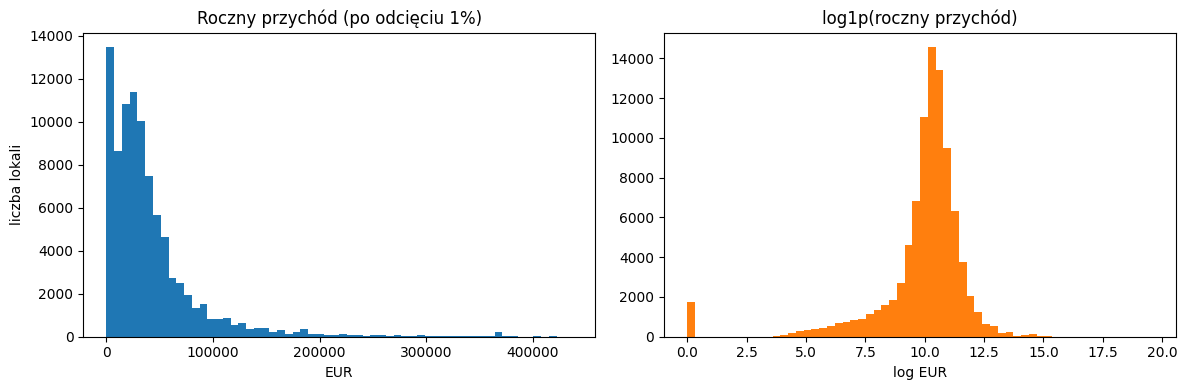

In [2]:
print(df[TARGET].describe())
cap = df[TARGET].quantile(0.99)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df[df[TARGET] <= cap][TARGET], bins=60)
ax[0].set(title='Roczny przychód (po odcięciu 1%)', xlabel='EUR', ylabel='liczba lokali')
ax[1].hist(np.log1p(df[TARGET]), bins=60, color='tab:orange')
ax[1].set(title='log1p(roczny przychód)', xlabel='log EUR')
fig.tight_layout(); fig.savefig(FIG / 'eda_target_distribution.png', dpi=110); plt.show()

## 2. Przychód wg dzielnicy
Różnice **między** dzielnicami są niewielkie w porównaniu z rozrzutem **wewnątrz** dzielnic — dlatego prosty model „średnia dzielnicy" będzie słaby (R²≈0).

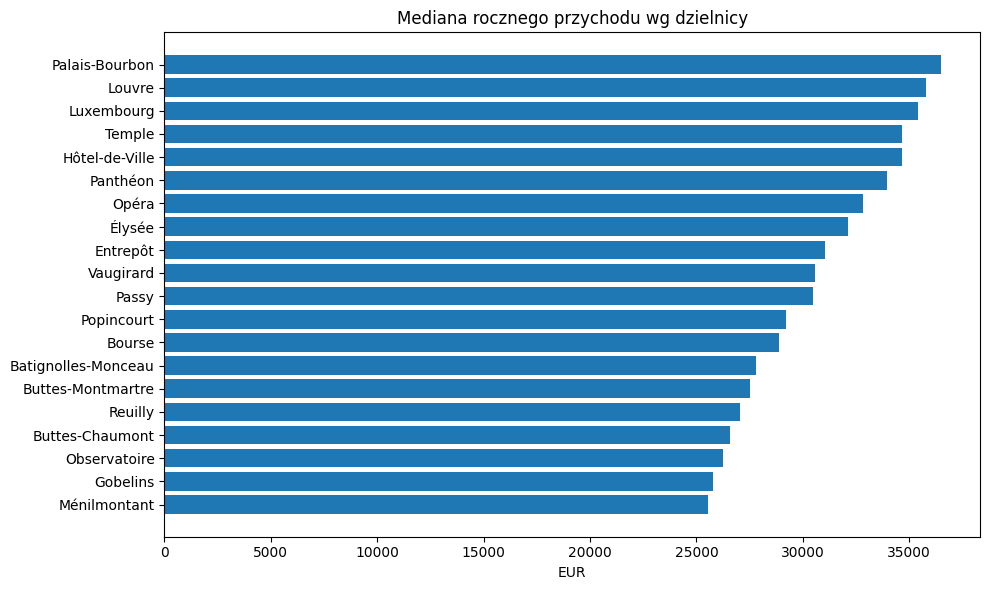

Odch. std median MIEDZY dzielnicami: 3,670 EUR
Srednie odch. std WEWNATRZ dzielnic: 49,367 EUR


In [3]:
cap = df[TARGET].quantile(0.99); d = df[df[TARGET] <= cap]
order = d.groupby('neighbourhood_cleansed')[TARGET].median().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(order.index, order.values)
ax.set(title='Mediana rocznego przychodu wg dzielnicy', xlabel='EUR')
fig.tight_layout(); fig.savefig(FIG / 'eda_revenue_by_district.png', dpi=110); plt.show()
between = order.std(); within = d.groupby('neighbourhood_cleansed')[TARGET].std().mean()
print(f'Odch. std median MIEDZY dzielnicami: {between:,.0f} EUR')
print(f'Srednie odch. std WEWNATRZ dzielnic: {within:,.0f} EUR')

## 3. Konkurencja (gęstość ofert) a przychód
Cecha `comp_count_500m` to liczba lokali w promieniu 500 m (saturacja rynku z Canvas).

In [4]:
corr = d[['accommodates','amenities_count','comp_count_250m','comp_count_500m',
          'comp_count_1000m','district_median_price','district_mean_review_location',TARGET]].corr()[TARGET]
print('Korelacja cech numerycznych z celem:')
print(corr.sort_values(ascending=False).to_string())

Korelacja cech numerycznych z celem:
annual_revenue                   1.000000
accommodates                     0.302782
district_median_price            0.138138
amenities_count                  0.122488
district_mean_review_location    0.116576
comp_count_1000m                 0.003616
comp_count_500m                 -0.007121
comp_count_250m                 -0.010709


## Wnioski
- Cel jest prawoskośny → odcinamy górny 1% (dane o nierealnych cenach).
- Zmienność przychodu **wewnątrz** dzielnic znacznie przewyższa zmienność **między** nimi → baseline „średnia dzielnicy" nie wystarczy.
- Najsilniejsze cechy: `accommodates`, `district_median_price`, gęstość konkurencji → model docelowy (HGB) powinien je wykorzystać.
- Świadomie **nie** używamy własnej ceny/ocen lokalu (to wynik po starcie, niedostępny dla nowej oferty → unikamy wycieku danych).